In [1]:
#modificaciones 22/01/2025

import os
import anndata as ad
import scanpy as sc
import numpy as np
import logging
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp

logging.basicConfig(filename='/app/project/restore_data/pipeline_articulo/3.5normalized&scaled_by_group/processing_errors.log', level=logging.ERROR)


def plot_count_distribution(adata, title):
    plt.figure(figsize=(10, 5))
    sc.pl.highest_expr_genes(adata, n_top=20, show=False)
    plt.title(title)
    plt.tight_layout()
    plt.savefig(f"{title.replace(' ', '_')}.png")
    plt.close()

def plot_hvg(adata):
    plt.figure(figsize=(10, 5))
    sc.pl.highly_variable_genes(adata, show=False)
    plt.tight_layout()
    plt.savefig("/app/project/restore_data/pipeline_articulo/3.5normalized&scaled_by_group/highly_variable_genes.png")
    plt.close()

def plot_hvg_heatmap(adata):
    plt.figure(figsize=(12, 8))
    sc.pl.heatmap(adata, var_names=adata.var.highly_variable.sort_values(ascending=False).head(50).index, 
                  groupby='source_file', show_gene_labels=True, show=False)
    plt.title("Top 50 Highly Variable Genes")
    plt.tight_layout()
    plt.savefig("/app/project/restore_data/pipeline_articulo/3.5normalized&scaled_by_group/hvg_heatmap.png")
    plt.close()

def plot_pca(adata):
    sc.tl.pca(adata)
    plt.figure(figsize=(10, 5))
    sc.pl.pca(adata, color='source_file', show=False)
    plt.tight_layout()
    plt.savefig("/app/project/restore_data/pipeline_articulo/3.5normalized&scaled_by_group/pca_plot.png")
    plt.close()
    
import os
import anndata as ad
import scanpy as sc
import numpy as np
import logging
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp

logging.basicConfig(filename='/app/project/restore_data/pipeline_articulo/3.5normalized&scaled_by_group/processing_errors.log', level=logging.ERROR)

def process_data(input_dir, output_dir):
    os.makedirs(output_dir, exist_ok=True)
    
    for filename in os.listdir(input_dir):
        if filename.endswith('.h5ad'):
            input_file = os.path.join(input_dir, filename)
            output_file = os.path.join(output_dir, f"processed_{filename}")
            
            try:
                # Cargar el archivo h5ad
                adata = ad.read_h5ad(input_file)
                print(f"Procesando archivo: {filename}")
                print(f"Forma inicial: {adata.shape}")
                
                # Asegurarse de que X sea float32 o float64 antes de las operaciones
                if sp.issparse(adata.X):
                    adata.X = adata.X.astype('float32')
                else:
                    adata.X = adata.X.astype('float32')
                
                # 1. Guardar counts en layers
                adata.layers['counts'] = adata.X.copy()

                # 2. Guardar estado raw para referencia
                adata.raw = adata
                
                # 3. Calcular HVG usando los datos crudos
                try:
                    if 'short_title' in adata.obs.columns:
                        sc.pp.highly_variable_genes(adata, 
                                                 flavor='seurat_v3',
                                                 n_top_genes=7000,
                                                 batch_key='short_title',
                                                 layer='counts',  # Usar los datos crudos
                                                 subset=False)  # No hacer subset aquí
                    else:
                        sc.pp.highly_variable_genes(adata, 
                                                 flavor='seurat_v3',
                                                 n_top_genes=7000,
                                                 layer='counts',  # Usar los datos crudos
                                                 subset=False)  # No hacer subset aquí
                except Exception as e:
                    print(f"Error en HVG: {str(e)}")
                    raise
                
                # 4. Guardar los genes HVG
                hvg_genes = adata.var_names[adata.var.highly_variable]
                adata.uns['hvg_genes'] = hvg_genes.tolist()
                
                # 5. Normalización
                try:
                    sc.pp.normalize_total(adata, target_sum=1e4)
                except Exception as e:
                    print(f"Error en normalización: {str(e)}")
                    raise
                
                sc.pp.log1p(adata)
                
                # 6. Ahora sí hacemos el subset a HVG
                adata = adata[:, adata.var.highly_variable]
                
                # 7. Regresión de efectos no deseados (si aplica)
                if 'n_counts' in adata.obs:
                    try:
                        sc.pp.regress_out(adata, ['n_counts'])
                    except Exception as e:
                        print(f"Error en regress_out: {str(e)}")
                        # Continuamos incluso si falla la regresión
                
                # 8. Escalado controlado por tipo celular
                try:
                    print("Iniciando escalado por tipo celular...")
                    
                    # Crear una copia de los datos sin escalar
                    if 'unscaled' not in adata.layers:
                        adata.layers['unscaled'] = adata.X.copy()
                    
                    # Escalado por tipo celular
                    for cell_type in adata.obs['cell_type'].unique():
                        print(f"Escalando células de tipo: {cell_type}")
                        # Crear máscara para el tipo celular actual
                        mask = adata.obs['cell_type'] == cell_type
                        
                        # Escalar solo las células del tipo actual
                        if sp.issparse(adata.X):
                            # Convertir a array denso solo la porción que necesitamos
                            subset = adata[mask].X.toarray()
                            # Escalar
                            subset_scaled = sc.pp.scale(subset, 
                                                      max_value=5,
                                                      zero_center=True,
                                                      copy=True)
                            # Volver a formato sparse
                            adata[mask].X = sp.csr_matrix(subset_scaled)
                        else:
                            adata[mask].X = sc.pp.scale(adata[mask].X,
                                                      max_value=5,
                                                      zero_center=True,
                                                      copy=True)
                    
                    print("Escalado por tipo celular completado")
                
                except Exception as e:
                    print(f"Error en escalado por tipo celular: {str(e)}")
                    raise
                
                # 9. Métricas de QC
                adata.obs['n_genes'] = (adata.X > 0).sum(axis=1)
                if sp.issparse(adata.X):
                    adata.obs['n_counts'] = adata.X.sum(axis=1).A1
                else:
                    adata.obs['n_counts'] = adata.X.sum(axis=1)
                
                # 10. Información de procesamiento
                adata.uns['processing_info'] = {
                    'n_hvg': len(adata.uns['hvg_genes']),
                    'normalization': 'log1p_with_total_norm',
                    'scaling': 'scaled_with_max_value_5'
                }
                
                # Visualizaciones
                plot_hvg(adata)
                plot_hvg_heatmap(adata)
                plot_pca(adata)
                
                # Guardar el resultado
                adata.write_h5ad(output_file)
                print(f"Procesamiento completado para {filename}")
                
            except Exception as e:
                logging.error(f"Error al procesar {filename}: {str(e)}")
                print(f"Error al procesar {filename}. Ver log para detalles.")
                continue

# Uso del script
input_directory = '/app/project/restore_data/pipeline_articulo/3.doublet_removal'
output_directory = '/app/project/restore_data/pipeline_articulo/3.5normalized&scaled_by_group'
process_data(input_directory, output_directory)

Procesando archivo: filtered_filtered_NK cells_data.h5ad
Forma inicial: (339144, 7000)


/root/.pyenv/versions/3.9.7/lib/python3.9/site-packages/scanpy/preprocessing/_simple.py:668: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


Iniciando escalado por tipo celular...
Escalando células de tipo: CD16-positive, CD56-dim natural killer cell, human
Escalando células de tipo: CD16-negative, CD56-bright natural killer cell, human
Escalando células de tipo: natural killer cell
Escalando células de tipo: type I NK T cell
Escalando células de tipo: activated type II NK T cell
Escalando células de tipo: mature NK T cell
Escalado por tipo celular completado


/tmp/ipykernel_1523/3596298689.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Procesamiento completado para filtered_filtered_NK cells_data.h5ad


<Figure size 1000x500 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

In [3]:
def evaluate_preprocessing(adata, batch_key='short_title', cell_type_key=None):
    """
    Evalúa comprensivamente el preprocesamiento de datos.
    
    Parameters:
    -----------
    adata : AnnData
        Objeto AnnData procesado
    batch_key : str
        Nombre de la columna que identifica los batches
    cell_type_key : str
        Nombre de la columna que identifica tipos celulares
    """
    # Crear directorio para plots
    os.makedirs('preprocessing_evaluation', exist_ok=True)
    
    # 1. PCA y visualizaciones básicas
    sc.tl.pca(adata)
    
    # 2. Evaluación de varianza
    plt.figure(figsize=(10, 5))
    sc.pl.pca_variance_ratio(adata, log=True, save='_variance_ratio.pdf')
    
    # 3. Visualización de batches
    plt.figure(figsize=(12, 6))
    sc.pl.pca(adata, color=batch_key, save='_batch_distribution.pdf')
    
    # 4. Visualización de tipos celulares si están disponibles
    if cell_type_key and cell_type_key in adata.obs:
        plt.figure(figsize=(12, 6))
        sc.pl.pca(adata, color=cell_type_key, save='_cell_types.pdf')
    
    # 5. Métricas cuantitativas
    metrics = {
        'n_cells': adata.n_obs,
        'n_genes': adata.n_vars,
        'n_hvg': len(adata.uns.get('hvg_genes', [])),
        'variance_explained_top10_PCs': np.sum(adata.uns['pca']['variance_ratio'][:10]),
        'n_batches': len(adata.obs[batch_key].unique())
    }
    
    # Guardar métricas
    with open('preprocessing_evaluation/metrics.txt', 'w') as f:
        for key, value in metrics.items():
            f.write(f"{key}: {value}\n")
    
    return metrics

In [4]:
import scanpy as sc
adata= sc.read_h5ad('/app/project/test_data/pipeline_articulo/3.5normalized&scaled_by_group/processed_filtered_filtered_NK cells_data.h5ad')


<Figure size 1000x500 with 0 Axes>

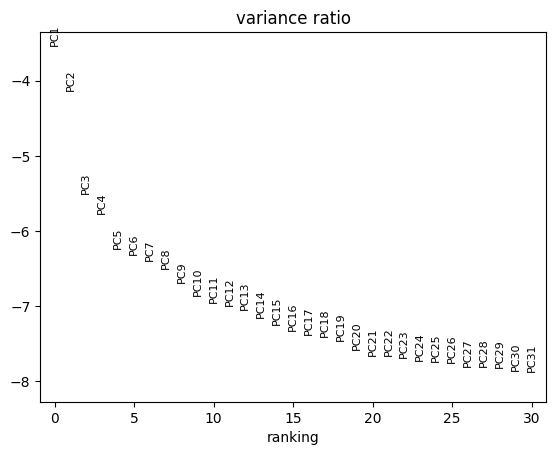

<Figure size 1200x600 with 0 Axes>

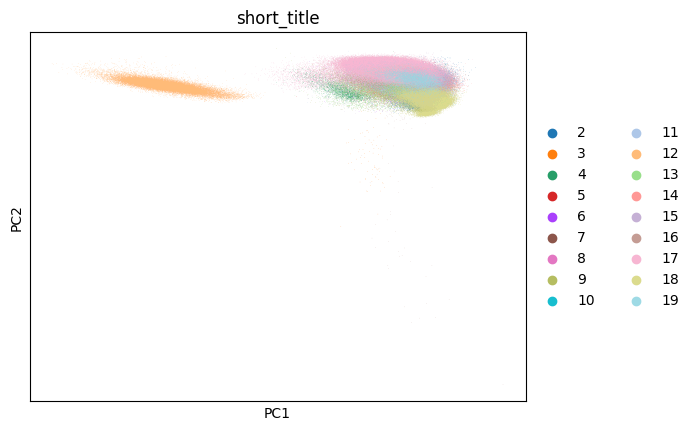

Métricas de preprocesamiento: {'n_cells': 324602, 'n_genes': 10000, 'n_hvg': 10000, 'variance_explained_top10_PCs': 0.06171183469897371, 'n_batches': 18}


In [5]:
# Dentro de tu bucle principal
    
import os
import anndata as ad
import scanpy as sc
import numpy as np
import logging
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
metrics = evaluate_preprocessing(adata, batch_key='short_title')
print("Métricas de preprocesamiento:", metrics)